In [1]:
# https://www.bioconductor.org/packages/release/bioc/vignettes/GSVA/inst/doc/GSVA.html

In [2]:
# The GSVA package provides the implementation of four single-sample gene set enrichment methods, 
# concretely zscore, plage, ssGSEA and its own called GSVA

In [3]:
# We import the PBMC data using the TENxPBMCData package :

In [4]:
library(SingleCellExperiment)
library(TENxPBMCData)

sce <- TENxPBMCData(dataset="pbmc4k")
sce

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

class: SingleCellExperiment 
dim: 33694 4340 
metadata(0):
assays(1): counts
rownames(33694): ENSG00000243485 ENSG00000237613 ... ENSG00000277475
  ENSG00000268674
rowData names(3): ENSEMBL_ID Symbol_TENx Symbol
colnames: NULL
colData names(11): Sample Barcode ... Individual Date_published
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [5]:
head(rownames(sce))
tail(rownames(sce))

[1] "ENSG00000243485" "ENSG00000237613" "ENSG00000186092" "ENSG00000238009"
[5] "ENSG00000239945" "ENSG00000239906"

[1] "ENSG00000276345" "ENSG00000277856" "ENSG00000275063" "ENSG00000271254"
[5] "ENSG00000277475" "ENSG00000268674"

In [6]:
colData(sce)

DataFrame with 4340 rows and 11 columns
          Sample            Barcode         Sequence   Library
     <character>        <character>      <character> <integer>
1         pbmc4k AAACCTGAGAAGGCCT-1 AAACCTGAGAAGGCCT         1
2         pbmc4k AAACCTGAGACAGACC-1 AAACCTGAGACAGACC         1
3         pbmc4k AAACCTGAGATAGTCA-1 AAACCTGAGATAGTCA         1
4         pbmc4k AAACCTGAGCGCCTCA-1 AAACCTGAGCGCCTCA         1
5         pbmc4k AAACCTGAGGCATGGT-1 AAACCTGAGGCATGGT         1
...          ...                ...              ...       ...
4336      pbmc4k TTTGGTTTCGCTAGCG-1 TTTGGTTTCGCTAGCG         1
4337      pbmc4k TTTGTCACACTTAACG-1 TTTGTCACACTTAACG         1
4338      pbmc4k TTTGTCACAGGTCCAC-1 TTTGTCACAGGTCCAC         1
4339      pbmc4k TTTGTCAGTTAAGACA-1 TTTGTCAGTTAAGACA         1
4340      pbmc4k TTTGTCATCCCAAGAT-1 TTTGTCATCCCAAGAT         1
     Cell_ranger_version Tissue_status Barcode_type   Chemistry
             <character>   <character>  <character> <character>
1            

In [7]:
rowData(sce)

DataFrame with 33694 rows and 3 columns
                     ENSEMBL_ID  Symbol_TENx       Symbol
                    <character>  <character>  <character>
ENSG00000243485 ENSG00000243485 RP11-34P13.3           NA
ENSG00000237613 ENSG00000237613      FAM138A      FAM138A
ENSG00000186092 ENSG00000186092        OR4F5        OR4F5
ENSG00000238009 ENSG00000238009 RP11-34P13.7 LOC100996442
ENSG00000239945 ENSG00000239945 RP11-34P13.8           NA
...                         ...          ...          ...
ENSG00000277856 ENSG00000277856   AC233755.2           NA
ENSG00000275063 ENSG00000275063   AC233755.1 LOC102723407
ENSG00000271254 ENSG00000271254   AC240274.1 LOC102724250
ENSG00000277475 ENSG00000277475   AC213203.1           NA
ENSG00000268674 ENSG00000268674      FAM231B      FAM231C

In [8]:
assayNames(sce)

[1] "counts"

In [9]:
dim(assay(sce, "counts"))
assay(sce, "counts")

[1] 33694  4340

<33694 x 4340> sparse DelayedMatrix object of type "integer":
                   [,1]    [,2]    [,3]    [,4] ... [,4337] [,4338] [,4339]
ENSG00000243485       0       0       0       0   .       0       0       0
ENSG00000237613       0       0       0       0   .       0       0       0
ENSG00000186092       0       0       0       0   .       0       0       0
ENSG00000238009       0       0       0       0   .       0       0       0
ENSG00000239945       0       0       0       0   .       0       0       0
            ...       .       .       .       .   .       .       .       .
ENSG00000277856       0       0       0       0   .       0       0       0
ENSG00000275063       0       0       0       0   .       0       0       0
ENSG00000271254       0       0       0       0   .       0       0       0
ENSG00000277475       0       0       0       0   .       0       0       0
ENSG00000268674       0       0       0       0   .       0       0       0
                [,4340]
EN

In [10]:
cat("Add log-normalized counts")

library(scuttle)
sce <- logNormCounts(sce)

Add log-normalized counts

Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”


In [11]:
assayNames(sce)

[1] "counts"    "logcounts"

In [12]:
cat("Annotate cell types using GSVA")

Annotate cell types using GSVA

In [13]:
library(GSEABase)
library(GSVA)

fname <- file.path(system.file("extdata", package="GSVAdata"),
                   "pbmc_cell_type_gene_set_signatures.gmt.gz")
gsets <- readGMT(fname)
gsets

Loading required package: annotate

Loading required package: AnnotationDbi

Loading required package: XML

Loading required package: graph


Attaching package: ‘graph’


The following object is masked from ‘package:XML’:

    addNode




GeneSetCollection
  names: B_CELLS_MEMORY, B_CELLS_NAIVE, ..., T_CELLS_REGULATORY_TREGS (22 total)
  unique identifiers: AIM2, BANK1, ..., SKAP1 (248 total)
  types in collection:
    geneIdType: SymbolIdentifier (1 total)
    collectionType: NullCollection (1 total)

In [14]:
# str(gsets)

In [15]:
names(gsets)

[1] "B_CELLS_MEMORY"               "B_CELLS_NAIVE"               
 [3] "DENDRITIC_CELLS_ACTIVATED"    "DENDRITIC_CELLS_RESTING"     
 [5] "EOSINOPHILS"                  "MACROPHAGES_M0"              
 [7] "MACROPHAGES_M1"               "MACROPHAGES_M2"              
 [9] "MAST_CELLS_ACTIVATED"         "MAST_CELLS_RESTING"          
[11] "MONOCYTES"                    "NEUTROPHILS"                 
[13] "NK_CELLS_ACTIVATED"           "NK_CELLS_RESTING"            
[15] "PLASMA_CELLS"                 "T_CELLS_CD4_MEMORY_ACTIVATED"
[17] "T_CELLS_CD4_MEMORY_RESTING"   "T_CELLS_CD4_NAIVE"           
[19] "T_CELLS_CD8"                  "T_CELLS_FOLLICULAR_HELPER"   
[21] "T_CELLS_GAMMA_DELTA"          "T_CELLS_REGULATORY_TREGS"

In [16]:
geneIds(gsets)

$B_CELLS_MEMORY
 [1] "AIM2"      "BANK1"     "BLK"       "CD19"      "CD27"      "CD37"     
 [7] "CD69"      "CD79A"     "CD79B"     "FAIM3"     "FAM65B"    "FCGR2B"   
[13] "FCRL2"     "GUSBP11"   "HLA-DOB"   "IGHM"      "IGKC"      "IGLL3P"   
[19] "IRF8"      "KIAA0226L" "LTB"       "LY86"      "MS4A1"     "P2RX5"    
[25] "PNOC"      "PTPRCAP"   "RASGRP2"   "SELL"      "SIK1"      "SPIB"     

$B_CELLS_NAIVE
 [1] "BACH2"     "BANK1"     "CCR7"      "CD19"      "CD22"      "CD37"     
 [7] "CD69"      "CD79A"     "CD79B"     "EAF2"      "FAIM3"     "FAM65B"   
[13] "FCGR2B"    "FCRL2"     "GPR18"     "GUSBP11"   "HHEX"      "HLA-DOB"  
[19] "IGHD"      "IGHM"      "IGKC"      "IGLL3P"    "IL4R"      "IRF8"     
[25] "KIAA0226L" "LTB"       "LY86"      "MS4A1"     "P2RX5"     "PNOC"     
[31] "PTPRCAP"   "RASGRP2"   "SELL"      "SIK1"      "SPIB"      "STAP1"    
[37] "TCL1A"     "VPREB3"   

$DENDRITIC_CELLS_ACTIVATED
 [1] "ACP5"     "BCL2A1"   "BIRC3"    "CCL13"    "CCL17"    "CCL19"   
 [7] "CCL22"    "CCL4"     "CCL5"     "CCR7"     "CD38"     "CD40"    
[13] "CD80"     "CD86"     "CHST7"    "CLIC2"    "CST7"     "CXCL10"  
[19] "CXCL11"   "EBI3"     "FPR3"     "HCK"      "HLA-DQA1" "IDO1"    
[25] "IFI44L"   "IL7R"     "KYNU"     "LAMP3"    "MMP12"    "NCF2"    
[31] "PLA2G7"   "RGS1"     "RSAD2"    "SAMSN1"   "SLC15A3"  "TNFAIP6" 

$DENDRITIC_CELLS_RESTING
 [1] "ACP5"     "AIF1"     "C1ORF54"  "CCL13"    "CCL22"    "CD1A"    
 [7] "CD1B"     "CD1C"     "CD1E"     "CLEC10A"  "CLEC4A"   "CLEC7A"  
[13] "EGR2"     "FPR3"     "HCK"      "HLA-DQA1" "IGSF6"    "LST1"    
[19] "MMP12"    "MMP9"     "MNDA"     "MS4A6A"   "NCF2"     "PLA2G7"  
[25] "RNASE6"   "SLC15A3"  "TREM2"   

$EOSINOPHILS
 [1] "BCL2A1" "C3AR1"  "CCL4"   "CCR3"   "CD69"   "CLC"    "DPEP2"  "EMR1"  
 [9] "EMR2"   "EMR3"   "FOSB"   "FPR1"   "GPR183" "GPR65"  "GPR97"  "HCK"   
[17] "LRMP"   "LST1"   "MNDA"   "MYB"    "NCF2"   "NR4A3"  "P2RY14" "RGS1"  
[25] "RNASE2" "SAMSN1" "SELL"   "ZNF165"

$MACROPHAGES_M0
 [1] "ACP5"     "ADAMDEC1" "AQP9"     "BCL2A1"   "BHLHE41"  "C5AR1"   
 [7] "CHI3L1"   "CLEC7A"   "CXCL5"    "CYP27A1"  "DCSTAMP"  "EGR2"    
[13] "FPR3"     "HCK"      "HK3"      "IGSF6"    "IL7R"     "KYNU"    
[19] "MMP9"     "NCF2"     "PLA2G7"   "PPBP"     "SLC15A3" 

$MACROPHAGES_M1
 [1] "ADAMDEC1" "APOBEC3A" "APOL3"    "AQP9"     "BCL2A1"   "C3AR1"   
 [7] "CCL19"    "CCL4"     "CCL5"     "CCL8"     "CCR7"     "CD38"    
[13] "CD40"     "CD80"     "CHI3L1"   "CXCL10"   "CXCL11"   "CXCL9"   
[19] "CYP27B1"  "EBI3"     "EMR1"     "HCK"      "HLA-DQA1" "IDO1"    
[25] "IFI44L"   "IL2RA"    "IL4R"     "IRF8"     "KYNU"     "LAMP3"   
[31] "LILRB2"   "MNDA"     "RASSF4"   "RSAD2"    "SAMSN1"   "SIGLEC1" 
[37] "SLAMF1"   "SLC15A3"  "SLC2A6"   "TLR2"     "TNFAIP6" 

$MACROPHAGES_M2
 [1] "ACP5"     "ADAMDEC1" "AIF1"     "CCL13"    "CCL18"    "CCL23"   
 [7] "CCL4"     "CD4"      "CLEC10A"  "CLEC4A"   "CLEC7A"   "HCK"     
[13] "HLA-DQA1" "IRF8"     "LY86"     "MMP9"     "MS4A6A"   "NCF2"    
[19] "NPL"      "RNASE6"   "SAMSN1"   "SIGLEC1"  "SLC15A3"  "TLR2"    
[25] "TREM2"   

$MAST_CELLS_ACTIVATED
 [1] "BCL2A1" "C3AR1"  "CCL20"  "CCL4"   "CLC"    "CPA3"   "CTSG"   "CXCL3" 
 [9] "ELANE"  "FCER1A" "GZMB"   "HDC"    "HPGDS"  "IL1B"   "IL4R"   "MMP9"  
[17] "MYB"    "PRG2"   "RGS13"  "SAMSN1" "TPSAB1"

$MAST_CELLS_RESTING
 [1] "ADRB2"  "C3AR1"  "CLC"    "CPA3"   "CTSG"   "ELANE"  "FCER1A" "HDC"   
 [9] "HPGDS"  "IL1B"   "IL4R"   "LAT"    "MS4A2"  "MYB"    "PRG2"   "SAMSN1"
[17] "STAP1"  "TPSAB1"

$MONOCYTES
 [1] "AIF1"    "C5AR1"   "CCL4"    "CD37"    "CD4"     "CFP"     "CHST15" 
 [8] "CLEC7A"  "FCN1"    "FOSB"    "FPR1"    "HCK"     "HK3"     "LILRB2" 
[15] "LST1"    "LY86"    "MNDA"    "MS4A6A"  "NCF2"    "RNASE2"  "RNASE6" 
[22] "S100A12" "SELL"    "TLR2"    "VNN2"   

$NEUTROPHILS
 [1] "AIF1"      "APOBEC3A"  "AQP9"      "BCL2A1"    "C5AR1"     "CD300A"   
 [7] "CD37"      "CDA"       "CHI3L1"    "CHST15"    "CLC"       "CLEC7A"   
[13] "CSF3R"     "C

In [17]:
# Note that while gene identifers in the sce object correspond to Ensembl stable identifiers (ENSG...), 
# the gene identifiers in the gene sets are HGNC gene symbol

In [18]:
# str(gsets)

In [19]:
gsvaAnnotation(sce) <- ENSEMBLIdentifier("org.Hs.eg.db")
gsvaAnnotation(sce)

geneIdType: ENSEMBL (org.Hs.eg.db)

In [20]:
cat("Build parameter object")
# By default, the expression values in the logocounts assay will be selected for downstream analysis.

Build parameter object

In [21]:
gsvapar <- gsvaParam(sce, gsets)
gsvapar

ℹ No assay name provided; using default assay 'logcounts'

Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
ℹ 593

A GSVA::gsvaParam object
expression data:
  class: SingleCellExperiment 
  dim: 33694 4340 
  metadata(1): annotation
  assays(2): counts logcounts
  rownames(33694): ENSG00000243485 ENSG00000237613 ... ENSG00000277475
    ENSG00000268674
  rowData names(3): ENSEMBL_ID Symbol_TENx Symbol
  colnames: NULL
  colData names(12): Sample Barcode ... Date_published sizeFactor
  reducedDimNames(0):
  mainExpName: NULL
  altExpNames(0):
using assay: logcounts
using annotation:
  geneIdType: ENSEMBL (org.Hs.eg.db)
gene sets:
  GeneSetCollection
    names: B_CELLS_MEMORY, B_CELLS_NAIVE, ..., T_CELLS_REGULATORY_TREGS (22 total)
    unique identifiers: AIM2, BANK1, ..., SKAP1 (248 total)
    types in collection:
      geneIdType: SymbolIdentifier (1 total)
      collectionType: NullCollection (1 total)
gene set size: [1, Inf]
kcdf: auto
kcdfNoneMinSampleSize: 200
tau: 1
maxDiff: TRUE
absRanking: FALSE
sparse:  TRUE 
checkNA: auto
missing data: didn't check
filterRows:  TRUE 
ondisk:  auto 
nonzero 

In [22]:
cat("Calculate GSVA scores")

Calculate GSVA scores

In [23]:
gsvaranks <- gsvaRanks(gsvapar)
gsvaranks

ℹ GSVA version 2.4.9

ℹ Maximum available main memory (90%): 27.858 GiB

ℹ On-disk input data fits in the maximum available main memory

ℹ Loading input expression data into main memory

Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish reso

A GSVA::gsvaRanksParam object
expression data:
  class: SingleCellExperiment 
  dim: 17700 4340 
  metadata(1): annotation
  assays(3): counts logcounts gsvaranks
  rownames(17700): ENSG00000238009 ENSG00000239945 ... ENSG00000276345
    ENSG00000271254
  rowData names(3): ENSEMBL_ID Symbol_TENx Symbol
  colnames: NULL
  colData names(12): Sample Barcode ... Date_published sizeFactor
  reducedDimNames(0):
  mainExpName: NULL
  altExpNames(0):
using assay: gsvaranks
using annotation:
  geneIdType: ENSEMBL (org.Hs.eg.db)
gene sets:
  GeneSetCollection
    names: B_CELLS_MEMORY, B_CELLS_NAIVE, ..., T_CELLS_REGULATORY_TREGS (22 total)
    unique identifiers: AIM2, BANK1, ..., SKAP1 (248 total)
    types in collection:
      geneIdType: SymbolIdentifier (1 total)
      collectionType: NullCollection (1 total)
gene set size: [1, Inf]
kcdf: auto
kcdfNoneMinSampleSize: 200
tau: 1
maxDiff: TRUE
absRanking: FALSE
sparse:  TRUE 
checkNA: auto
missing data: didn't check
filterRows:  TRUE 
ondisk: 

In [24]:
#  we calculate the GSVA scores using the output of gsvaRanks() as input to the function gsvaScores().

In [25]:
es <- gsvaScores(gsvaranks)
es

ℹ GSVA version 2.4.9

ℹ Mapping identifiers



ℹ GSVA sparse algorithm

ℹ Calculating GSVA scores

ℹ Splitting calculations in 2 chunks of [17700, 4224] and 285.205 MiB

Progress ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■    97% | ETA:  0s
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”

✔ Calculations finished



class: SingleCellExperiment 
dim: 22 4340 
metadata(0):
assays(1): es
rownames(22): B_CELLS_MEMORY B_CELLS_NAIVE ... T_CELLS_GAMMA_DELTA
  T_CELLS_REGULATORY_TREGS
rowData names(1): gs
colnames: NULL
colData names(12): Sample Barcode ... Date_published sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [26]:
class(es)
dim(es)

# gene sets x cells
# 20 4340

es[1:10, 1:10]

[1] "SingleCellExperiment"
attr(,"package")
[1] "SingleCellExperiment"

[1]   22 4340

class: SingleCellExperiment 
dim: 10 10 
metadata(0):
assays(1): es
rownames(10): B_CELLS_MEMORY B_CELLS_NAIVE ... MAST_CELLS_ACTIVATED
  MAST_CELLS_RESTING
rowData names(1): gs
colnames: NULL
colData names(12): Sample Barcode ... Date_published sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [27]:
head(rownames(es))
head(colnames(es))

[1] "B_CELLS_MEMORY"            "B_CELLS_NAIVE"            
[3] "DENDRITIC_CELLS_ACTIVATED" "DENDRITIC_CELLS_RESTING"  
[5] "EOSINOPHILS"               "MACROPHAGES_M0"

NULL

In [29]:
es["B_CELLS_MEMORY", ]

class: SingleCellExperiment 
dim: 1 4340 
metadata(0):
assays(1): es
rownames(1): B_CELLS_MEMORY
rowData names(1): gs
colnames: NULL
colData names(12): Sample Barcode ... Date_published sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [30]:
score.mat <- assay(es)

dim(score.mat)

score.mat[1:10,1:10]

head(rownames(score.mat))
head(colnames(score.mat))

[1]   22 4340

B_CELLS_MEMORY,0.0324935266,0.04724265,0.0339499664,0.05391585,0.149551249,0.13052022,0.109245831,0.034815584,0.254222588,0.46062178
B_CELLS_NAIVE,0.1575670063,0.12731047,0.1579892314,0.14952820,0.171643848,0.15693820,0.156918372,0.127338813,0.335372206,0.42516952
DENDRITIC_CELLS_ACTIVATED,-0.0371481658,-0.04441140,0.0476051028,-0.04741222,-0.048332198,-0.07092255,-0.049477621,-0.006249377,-0.084313024,0.06717358
DENDRITIC_CELLS_RESTING,0.0192056131,0.08254119,0.1035951964,-0.11142871,-0.098411108,-0.11060820,-0.093361751,0.238602924,-0.110412898,0.16178363
EOSINOPHILS,0.1244311255,0.13093899,0.2263263188,0.02499149,0.148073054,0.09990426,0.130135600,0.235331917,0.072472449,0.35607174
MACROPHAGES_M0,0.0285202011,0.08464853,0.0977995178,0.07332470,0.022991144,0.02679115,0.037300918,0.110549743,0.003700681,0.03045988
MACROPHAGES_M1,0.1131533552,0.09499334,0.1010161987,0.02042200,0.020281807,-0.00965809,0.061110581,-0.022644824,0.014591555,0.08271816
MACROPHAGES_M2,0.3105230781,0.29816960,0.2764525377,0.06335824,0.057761937,0.03762163,0.174135286,0.279128184,0.087826400,0.39779654
MAST_CELLS_ACTIVATED,0.0004806605,-0.01501357,0.0008199502,0.10586809,-0.009980774,-0.02536191,0.117071320,0.054815559,-0.005400362,-0.07800837
MAST_CELLS_RESTING,-0.1049417618,-0.11116137,-0.1056202646,0.01108758,-0.120321792,-0.12773837,0.009094648,0.041609097,-0.107768857,-0.13977157


[1] "B_CELLS_MEMORY"            "B_CELLS_NAIVE"            
[3] "DENDRITIC_CELLS_ACTIVATED" "DENDRITIC_CELLS_RESTING"  
[5] "EOSINOPHILS"               "MACROPHAGES_M0"

NULL

In [31]:
colData(es)

DataFrame with 4340 rows and 12 columns
          Sample            Barcode         Sequence   Library
     <character>        <character>      <character> <integer>
1         pbmc4k AAACCTGAGAAGGCCT-1 AAACCTGAGAAGGCCT         1
2         pbmc4k AAACCTGAGACAGACC-1 AAACCTGAGACAGACC         1
3         pbmc4k AAACCTGAGATAGTCA-1 AAACCTGAGATAGTCA         1
4         pbmc4k AAACCTGAGCGCCTCA-1 AAACCTGAGCGCCTCA         1
5         pbmc4k AAACCTGAGGCATGGT-1 AAACCTGAGGCATGGT         1
...          ...                ...              ...       ...
4336      pbmc4k TTTGGTTTCGCTAGCG-1 TTTGGTTTCGCTAGCG         1
4337      pbmc4k TTTGTCACACTTAACG-1 TTTGTCACACTTAACG         1
4338      pbmc4k TTTGTCACAGGTCCAC-1 TTTGTCACAGGTCCAC         1
4339      pbmc4k TTTGTCAGTTAAGACA-1 TTTGTCAGTTAAGACA         1
4340      pbmc4k TTTGTCATCCCAAGAT-1 TTTGTCATCCCAAGAT         1
     Cell_ranger_version Tissue_status Barcode_type   Chemistry
             <character>   <character>  <character> <character>
1            

In [32]:
colnames(colData(es))

[1] "Sample"              "Barcode"             "Sequence"           
 [4] "Library"             "Cell_ranger_version" "Tissue_status"      
 [7] "Barcode_type"        "Chemistry"           "Sequence_platform"  
[10] "Individual"          "Date_published"      "sizeFactor"

In [33]:
dim(score.mat)

[1]   22 4340

In [34]:
nrow(colData(es))

[1] 4340

In [35]:
cat("Using GSVA scores to assign cell types")
# https://bioconductor.org/books/3.16/OSCA.basic/clustering.html

Using GSVA scores to assign cell types

In [36]:
# we use GSVA scores to build a nearest-neighbor graph of the cells using the function buildSNNGraph() from the scran package

In [37]:
library(bluster)

g <- makeSNNGraph(t(assay(es)), k=20)

In [38]:
library(igraph)

colLabels(es) <- factor(cluster_walktrap(g)$membership)
table(colLabels(es))


Attaching package: ‘igraph’


The following object is masked from ‘package:GSEABase’:

    union


The following objects are masked from ‘package:graph’:

    degree, edges, intersection, union


The following object is masked from ‘package:HDF5Array’:

    path


The following object is masked from ‘package:h5mread’:

    path


The following objects are masked from ‘package:DelayedArray’:

    path, simplify


The following object is masked from ‘package:GenomicRanges’:

    union


The following object is masked from ‘package:IRanges’:

    union


The following object is masked from ‘package:S4Vectors’:

    union


The following objects are masked from ‘package:BiocGenerics’:

    normalize, path, union


The following objects are masked from ‘package:generics’:

    components, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union





   1    2    3    4    5    6 
1171 1185  861  616  162  345 

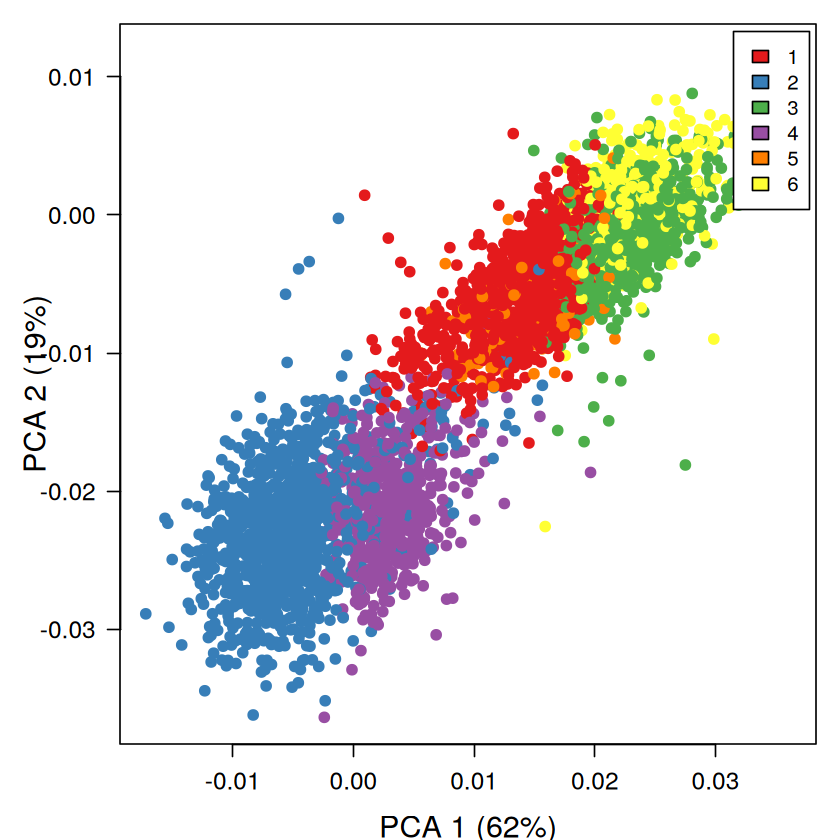

In [39]:
library(RColorBrewer)

res <- prcomp(assay(es))
varexp <- res$sdev^2 / sum(res$sdev^2)
nclusters <- nlevels(colLabels(es))
hmcol <- colorRampPalette(brewer.pal(nclusters, "Set1"))(nclusters)
par(mar=c(4, 5, 1, 1))
plot(res$rotation[, 1], res$rotation[, 2], col=hmcol[colLabels(es)], pch=19,
     xlab=sprintf("PCA 1 (%.0f%%)", varexp[1]*100),
     ylab=sprintf("PCA 2 (%.0f%%)", varexp[2]*100),
     las=1, cex.axis=1.2, cex.lab=1.5)
legend("topright", gsub("_", " ", levels(colLabels(es))), fill=hmcol, inset=0.01)

In [40]:
# if we want to better understand why a specific cell type is annotated to a given cell, we can use the gsvaEnrichment() function, 
# which will show a GSEA enrichment plot. 

In [41]:
# firsteosinophilcell <- which(colLabels(es) == "EOSINOPHILS")[1]
# par(mar=c(4, 5, 1, 1))

# gsvaEnrichment(gsvaranks, column=firsteosinophilcell, geneSet="EOSINOPHILS",
#               cex.axis=1.2, cex.lab=1.5, plot="ggplot")
